# 📘 Sales Data Analysis 

## 🎯 Objective

The objective of this task is to analyze the cleaned e-commerce dataset to understand business performance, identify trends, and generate actionable insights.

## 📂 Dataset Used

This analysis uses the cleaned dataset generated in Task 1:
cleaned_ecommerce_data.csv

## 🔷 1. Import Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

## 🔷 2. Load Cleaned Dataset

In [4]:
df = pd.read_csv("cleaned_ecommerce_data.csv")

df.head()

,id,_customer_name,order_id,order_date,product,_category,quantity,price,payment_method,status,total
0,100,Customer_100,ORD-41285,2024-11-22,Blender,Home,3.0,38.000,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2.0,542.195,PayPal,Processing,1084.39
2,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,Sports,1.0,389.050,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,2025-03-19,Science,Books,5.0,233.920,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,2025-10-20,Biography,Books,1.0,552.510,Cash on Delivery,Processing,552.51


## 🔷 3. Data Preparation

In [5]:
# Convert date column
df['order_date'] = pd.to_datetime(df['order_date'])

# Create month column for trend analysis
df['month'] = df['order_date'].dt.to_period('M')

## 📊 KPI ANALYSIS

### 🔷 4. Calculate KPIs

In [7]:
total_revenue = df['total'].sum()
total_orders = df['order_id'].nunique()
average_order_value = total_revenue / total_orders
total_units_sold = df['quantity'].sum()

top_category = df.groupby('_category')['total'].sum().idxmax()
top_product = df.groupby('product')['total'].sum().idxmax()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", average_order_value)
print("Total Units Sold:", total_units_sold)
print("Top Category:", top_category)
print("Top Product:", top_product)

Total Revenue: 156983.855
Total Orders: 97
Average Order Value: 1618.3902577319589
Total Units Sold: 297.0
Top Category: Books
Top Product: Comics


##  KPI Insights
* Total revenue indicates overall business performance
* Average order value helps understand customer spending behavior
* Top category and product highlight best-performing segments

## 🔷 5. KPI Summary Table

In [8]:
kpi_table = pd.DataFrame({
    "KPI": ["Total Revenue", "Total Orders", "Avg Order Value", "Total Units Sold", "Top Category", "Top Product"],
    "Value": [total_revenue, total_orders, average_order_value, total_units_sold, top_category, top_product]
})

kpi_table

,KPI,Value
0,Total Revenue,156983.855
1,Total Orders,97
2,Avg Order Value,1618.390258
3,Total Units Sold,297.0
4,Top Category,Books
5,Top Product,Comics


## 📈 TREND ANALYSIS

### 🔷 6. Monthly Sales Trend

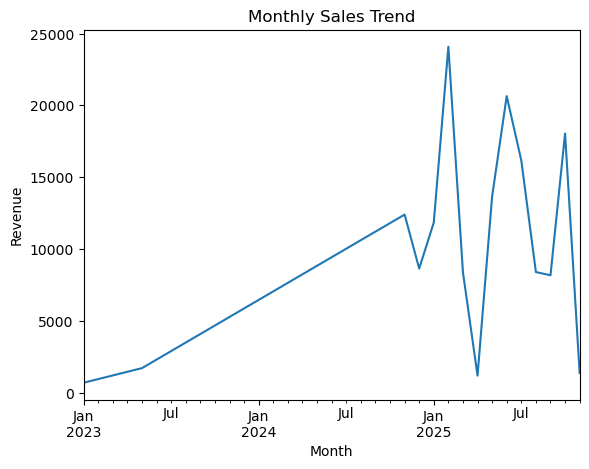

In [9]:
monthly_sales = df.groupby('month')['total'].sum()

plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

* Shows growth or decline over time

### 🔷 7. Category Performance Over Time

<Figure size 640x480 with 0 Axes>

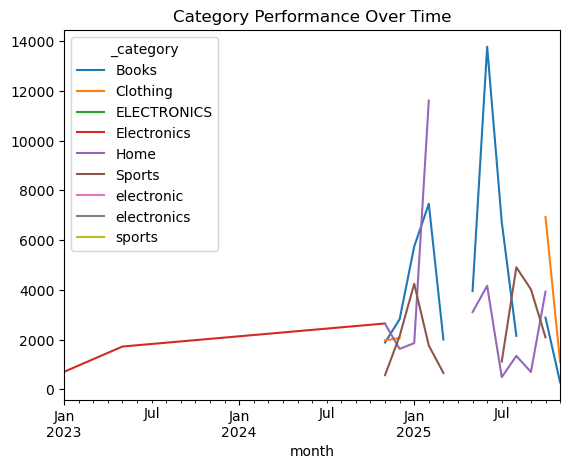

In [11]:
category_trend = df.groupby(['month', '_category'])['total'].sum().unstack()

plt.figure()
category_trend.plot()
plt.title("Category Performance Over Time")
plt.show()

* Identifies which categories are growing

### 🔷 8. Delivery Status Impact

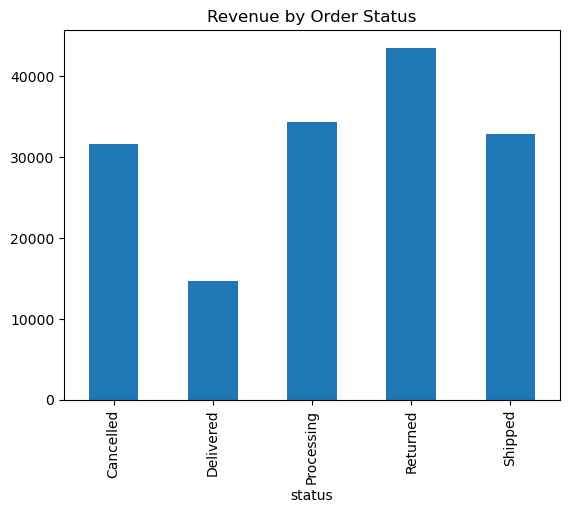

In [13]:
status_sales = df.groupby('status')['total'].sum()

plt.figure()
status_sales.plot(kind='bar')
plt.title("Revenue by Order Status")
plt.show()

* Helps understand how delivery affects revenue

## 👥 CUSTOMER INSIGHTS

### 🔷 9. Top Customers

In [15]:
top_customers = df.groupby('_customer_name')['total'].sum().sort_values(ascending=False).head(10)
top_customers

_customer_name
Customer_194    4722.70
Customer_149    4481.90
Customer_144    4245.35
Customer_143    4133.85
Customer_195    4087.30
Customer_154    3948.20
Customer_170    3708.15
Customer_126    3347.20
Customer_142    3226.30
Customer_131    3083.15
Name: total, dtype: float64

* Identifies high-value customers

### 🔷 10. Repeat Customers

In [16]:
repeat_customers = df['_customer_name'].value_counts()
repeat_customers.head()

_customer_name
Customer_100    1
Customer_152    1
Customer_174    1
Customer_173    1
Customer_172    1
Name: count, dtype: int64

* Shows customer loyalty

### 🔷 11. Orders by Payment Method

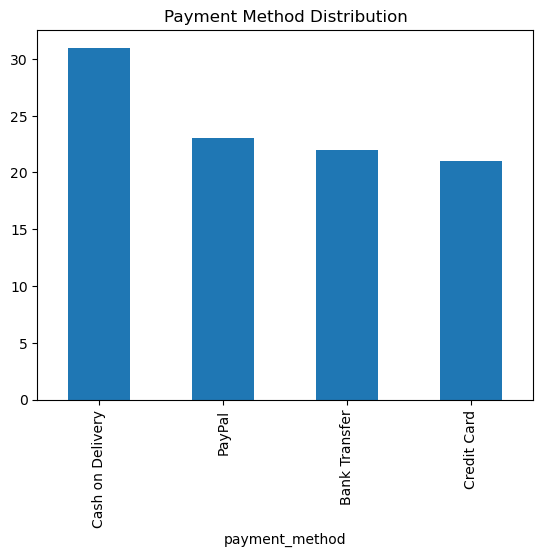

In [17]:
payment_counts = df['payment_method'].value_counts()

plt.figure()
payment_counts.plot(kind='bar')
plt.title("Payment Method Distribution")
plt.show()

* Shows customer payment preferences

## 📊 ANALYTICAL QUESTIONS

### 🔷 Highest Sales Month

In [19]:
monthly_sales.idxmax()

Period('2025-02', 'M')

### 🔷 Category with Highest Revenue

In [21]:
df.groupby('_category')['total'].sum().idxmax()

'Books'

## 📝 FINAL OBSERVATIONS 

### Key Observations

1. The business generated strong overall revenue with consistent order volume.
2. Certain product categories contribute significantly more to total sales.
3. Monthly sales trends indicate fluctuations, suggesting seasonal demand patterns.
4. A small group of customers contributes a large portion of revenue.
5. Payment method analysis shows customer preference for specific payment options.
6. Delivery status impacts revenue realization, with completed orders contributing most.

## 🚀 CONCLUSION

The sales analysis reveals key business insights including revenue drivers, customer behavior, and regional performance. 
These insights can help optimize marketing strategies, inventory planning, and customer engagement.